# Utilidades y plantillas para OpenCV

Este cuaderno reúne funciones cortas y reutilizables para la serie `computer_vision_parte_1`. La idea no es reemplazar a los cuadernos temáticos, sino dejar una caja de herramientas clara para cuando haga falta reducir fricción técnica.


## Objetivo

Centralizar helpers mínimos de carga, visualización y comparación para que los notebooks temáticos no repitan bloques largos de infraestructura.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- abrir imágenes en BGR o RGB;
- mostrar una o varias imágenes con un formato consistente;
- inspeccionar dimensiones básicas;
- reutilizar funciones cortas sin perder de vista qué hacen.


## Cómo conviene usar este cuaderno

- Ejecutalo una vez si querés tener los helpers a mano.
- Copiá solo lo necesario en otro notebook.
- No lo uses como caja negra: siempre revisá entradas, salidas y supuestos.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

CARPETA_IMAGENES = Path("Imagenes")

def abrir_imagen_bgr(nombre_archivo):
    '''Abre una imagen en BGR usando OpenCV.'''
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    return imagen_bgr

def abrir_imagen_rgb(nombre_archivo):
    '''Abre una imagen y la convierte a RGB para visualizarla con Matplotlib.'''
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    '''Muestra una sola imagen.'''
    plt.figure(figsize=tamano, constrained_layout=True)
    plt.imshow(imagen, cmap=mapa)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()

def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    '''Muestra varias imágenes lado a lado.'''
    if mapas is None:
        mapas = [None] * len(imagenes)
    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]
    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        eje.imshow(imagen, cmap=mapa)
        eje.set_title(titulo, fontweight="bold", loc="left")
        eje.axis("off")
    plt.show()

def mostrar_info_imagen(imagen, titulo="Imagen"):
    '''Imprime información básica de una imagen.'''
    print(f"{titulo}:")
    print(f"  Forma: {imagen.shape}")
    print(f"  Tipo de dato: {imagen.dtype}")
    print(f"  Valor mínimo: {imagen.min()}")
    print(f"  Valor máximo: {imagen.max()}")

print("Funciones listas para usar en la serie reescrita.")


Funciones listas para usar en la serie reescrita.


## Ejemplo mínimo de uso

El objetivo de este bloque no es enseñar un tema nuevo, sino mostrar cómo se invocan las funciones de manera simple.


Imagen de ejemplo:
  Forma: (417, 625, 3)
  Tipo de dato: uint8
  Valor mínimo: 0
  Valor máximo: 255


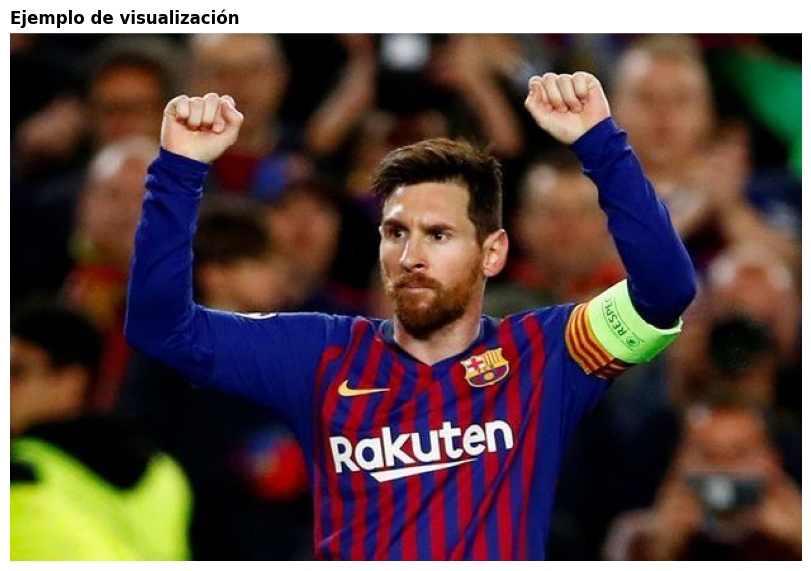

In [2]:
imagen_ejemplo = abrir_imagen_rgb("messi.jpg")
mostrar_info_imagen(imagen_ejemplo, "Imagen de ejemplo")
mostrar_una_imagen(imagen_ejemplo, "Ejemplo de visualización")


## Cierre

La función de este cuaderno es operativa: reducir repeticiones innecesarias sin esconder la lógica del trabajo. Si un notebook temático necesita una función, la idea es que la use de manera consciente y no como una plantilla opaca.
